In [16]:
import os

Collecting workspace informationHere's a comprehensive explanation of the HoleYeahFinal.ipynb notebook that you can share with an LLM:

---

## **HoleYea Model Training Notebook - Complete Breakdown**

### **Overview**
This is a **YOLOv8 object detection model training pipeline** for pothole detection. The notebook trains a custom YOLOv8 nano model on a pothole dataset and exports it to multiple formats (TFLite, ONNX) for mobile/edge deployment.

### **Key Sections & Flow**

#### **1. Setup & Initialization**
- **Imports**: `os`, `glob`, `IPython.display`
- **GPU Check**: `!nvidia-smi` — verifies CUDA availability
- **Home Directory**: Sets `HOME` to current working directory
- **Dependencies**: Installs `ultralytics` (YOLOv8), `fastapi`, `kaleido`, `python_multipart`, `uvicorn`

#### **2. Model Training**
- **Framework**: YOLOv8 Nano (`yolov8n.pt`)
- **Training Command**:
  ```
  yolo task=detect mode=train model=yolov8n.pt data=/content/datasets/data.yaml epochs=100 batch=32 imgsz=640 device=0 amp=True
  ```
- **Parameters**:
  - `epochs=100`: 100 training iterations
  - `batch=32`: Batch size of 32
  - `imgsz=640`: Input image size 640×640
  - `device=0`: GPU device 0
  - `amp=True`: Automatic Mixed Precision (faster training)
- **Dataset**: Requires `data.yaml` at `/content/datasets/data.yaml` with train/val/test splits

#### **3. Model Evaluation & Visualization**
- **Validation**: Runs validation on the best trained model (`best.pt`)
- **Outputs Generated**:
  - `confusion_matrix.png` — Class-wise confusion matrix
  - `results.png` — Training metrics (precision, recall, mAP, loss)
  - `val_batch0_pred.jpg` — Sample validation batch with predictions
- **Predictions**: Inference on test set with confidence threshold `conf=0.25`

#### **4. Model Export**
- **Best Model Path**: `{HOME}/runs/detect/train/weights/best.pt`
- **Export to TFLite**:
  ```python
  model = YOLO('/content/KaggleModel.pt')
  model.export(format='tflite')
  ```
- **Purpose**: Convert trained `.pt` model → `.tflite` for mobile deployment

---

### **Dataset Structure**


In [ ]:
/content/datasets/
├── data.yaml          # Dataset config (class names, paths)
├── images/
│   ├── train/        # Training images
│   ├── val/          # Validation images
│   └── test/         # Test images
└── labels/
    ├── train/        # Training annotations (YOLO format)
    ├── val/          # Validation annotations
    └── test/         # Test annotations



---

### **Model Details**

| Aspect | Value |
|--------|-------|
| **Architecture** | YOLOv8 Nano (smallest variant) |
| **Task** | Object Detection (single class: pothole) |
| **Input Size** | 640×640 pixels |
| **Output Format** | Bounding boxes + confidence scores |
| **Export Formats** | `.pt` (PyTorch), `.tflite` (TensorFlow Lite) |
| **Thresholds** | Confidence: 0.25, NMS: 0.45 (inferred from codebase) |

---

### **Output Models in Project**

Located in Android Models:
- **colabmodel.tflite** — Trained from Colab (TFLite format)
- **ColabModel.onnx** — Colab model in ONNX format
- **KaggleModel.tflite** — Kaggle dataset variant
- **KaggleModel.onnx** — Kaggle ONNX variant
- **labels.txt** — Class mapping: `0 pothole`

---

### **Integration with Mobile App**

The exported `.tflite` model is used in:
- **TFLiteService** — Loads & runs inference
- **Preprocessing**: Image resized to 640×640, YUV420→RGB conversion
- **Postprocessing**: Non-Maximum Suppression (NMS) to filter overlapping detections
- **Output**: List of `Detection` objects (x, y, width, height, confidence)

---

### **Training Artifacts Generated**


In [ ]:
/runs/detect/train/
├── weights/
│   ├── best.pt          # Best model checkpoint
│   └── last.pt          # Last epoch checkpoint
├── confusion_matrix.png
├── results.png
├── val_batch0_pred.jpg
└── ...other metrics



---

This notebook is a **standard YOLOv8 training pipeline** optimized for pothole detection with multi-format export capabilities for deployment across mobile (Flutter) and edge devices.

In [17]:
import glob

In [18]:
from IPython.display import Image, display

In [19]:
!nvidia-smi

Fri Apr 25 08:27:02 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   41C    P8              9W /   70W |       2MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [20]:
HOME = os.getcwd()

In [21]:
print(HOME)

/content


In [22]:
!pip install ultralytics

In [23]:
import ultralytics

In [24]:
ultralytics.checks()

Ultralytics 8.3.116 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 41.4/112.6 GB disk)


In [25]:
!mkdir {HOME}/datasets

mkdir: cannot create directory ‘/content/datasets’: File exists


In [26]:
%cd {HOME}/datasets

/content/datasets


In [13]:
!pip install fastapi kaleido python_multipart uvicorn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.2/95.2 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 MB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.5/62.5 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 7.8 MB/s eta 0:00:00


In [30]:
%cd {HOME}

/content


In [29]:
%cd {dataset.location}

[Errno 2] No such file or directory: '{dataset.location}'
/content/datasets


In [32]:
%cd {HOME}

!yolo task=detect mode=train model=yolov8n.pt data=/content/datasets/data.yaml epochs=100 batch=32 imgsz=640 device=0 amp=True


/content
100% 6.25M/6.25M [00:00<00:00, 124MB/s]
Ultralytics 8.3.116 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: task=detect, mode=train, model=yolov8n.pt, data=/content/datasets/data.yaml, epochs=100, time=None, patience=100, batch=32, imgsz=640, save=True, save_period=-1, cache=False, device=0, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels=Tr

In [33]:
!ls {HOME}//runs/detect/train

args.yaml			 R_curve.png	      train_batch2.jpg
confusion_matrix_normalized.png  results.csv	      val_batch0_labels.jpg
confusion_matrix.png		 results.png	      val_batch0_pred.jpg
F1_curve.png			 train_batch0.jpg     val_batch1_labels.jpg
labels_correlogram.jpg		 train_batch1440.jpg  val_batch1_pred.jpg
labels.jpg			 train_batch1441.jpg  val_batch2_labels.jpg
P_curve.png			 train_batch1442.jpg  val_batch2_pred.jpg
PR_curve.png			 train_batch1.jpg     weights


/content


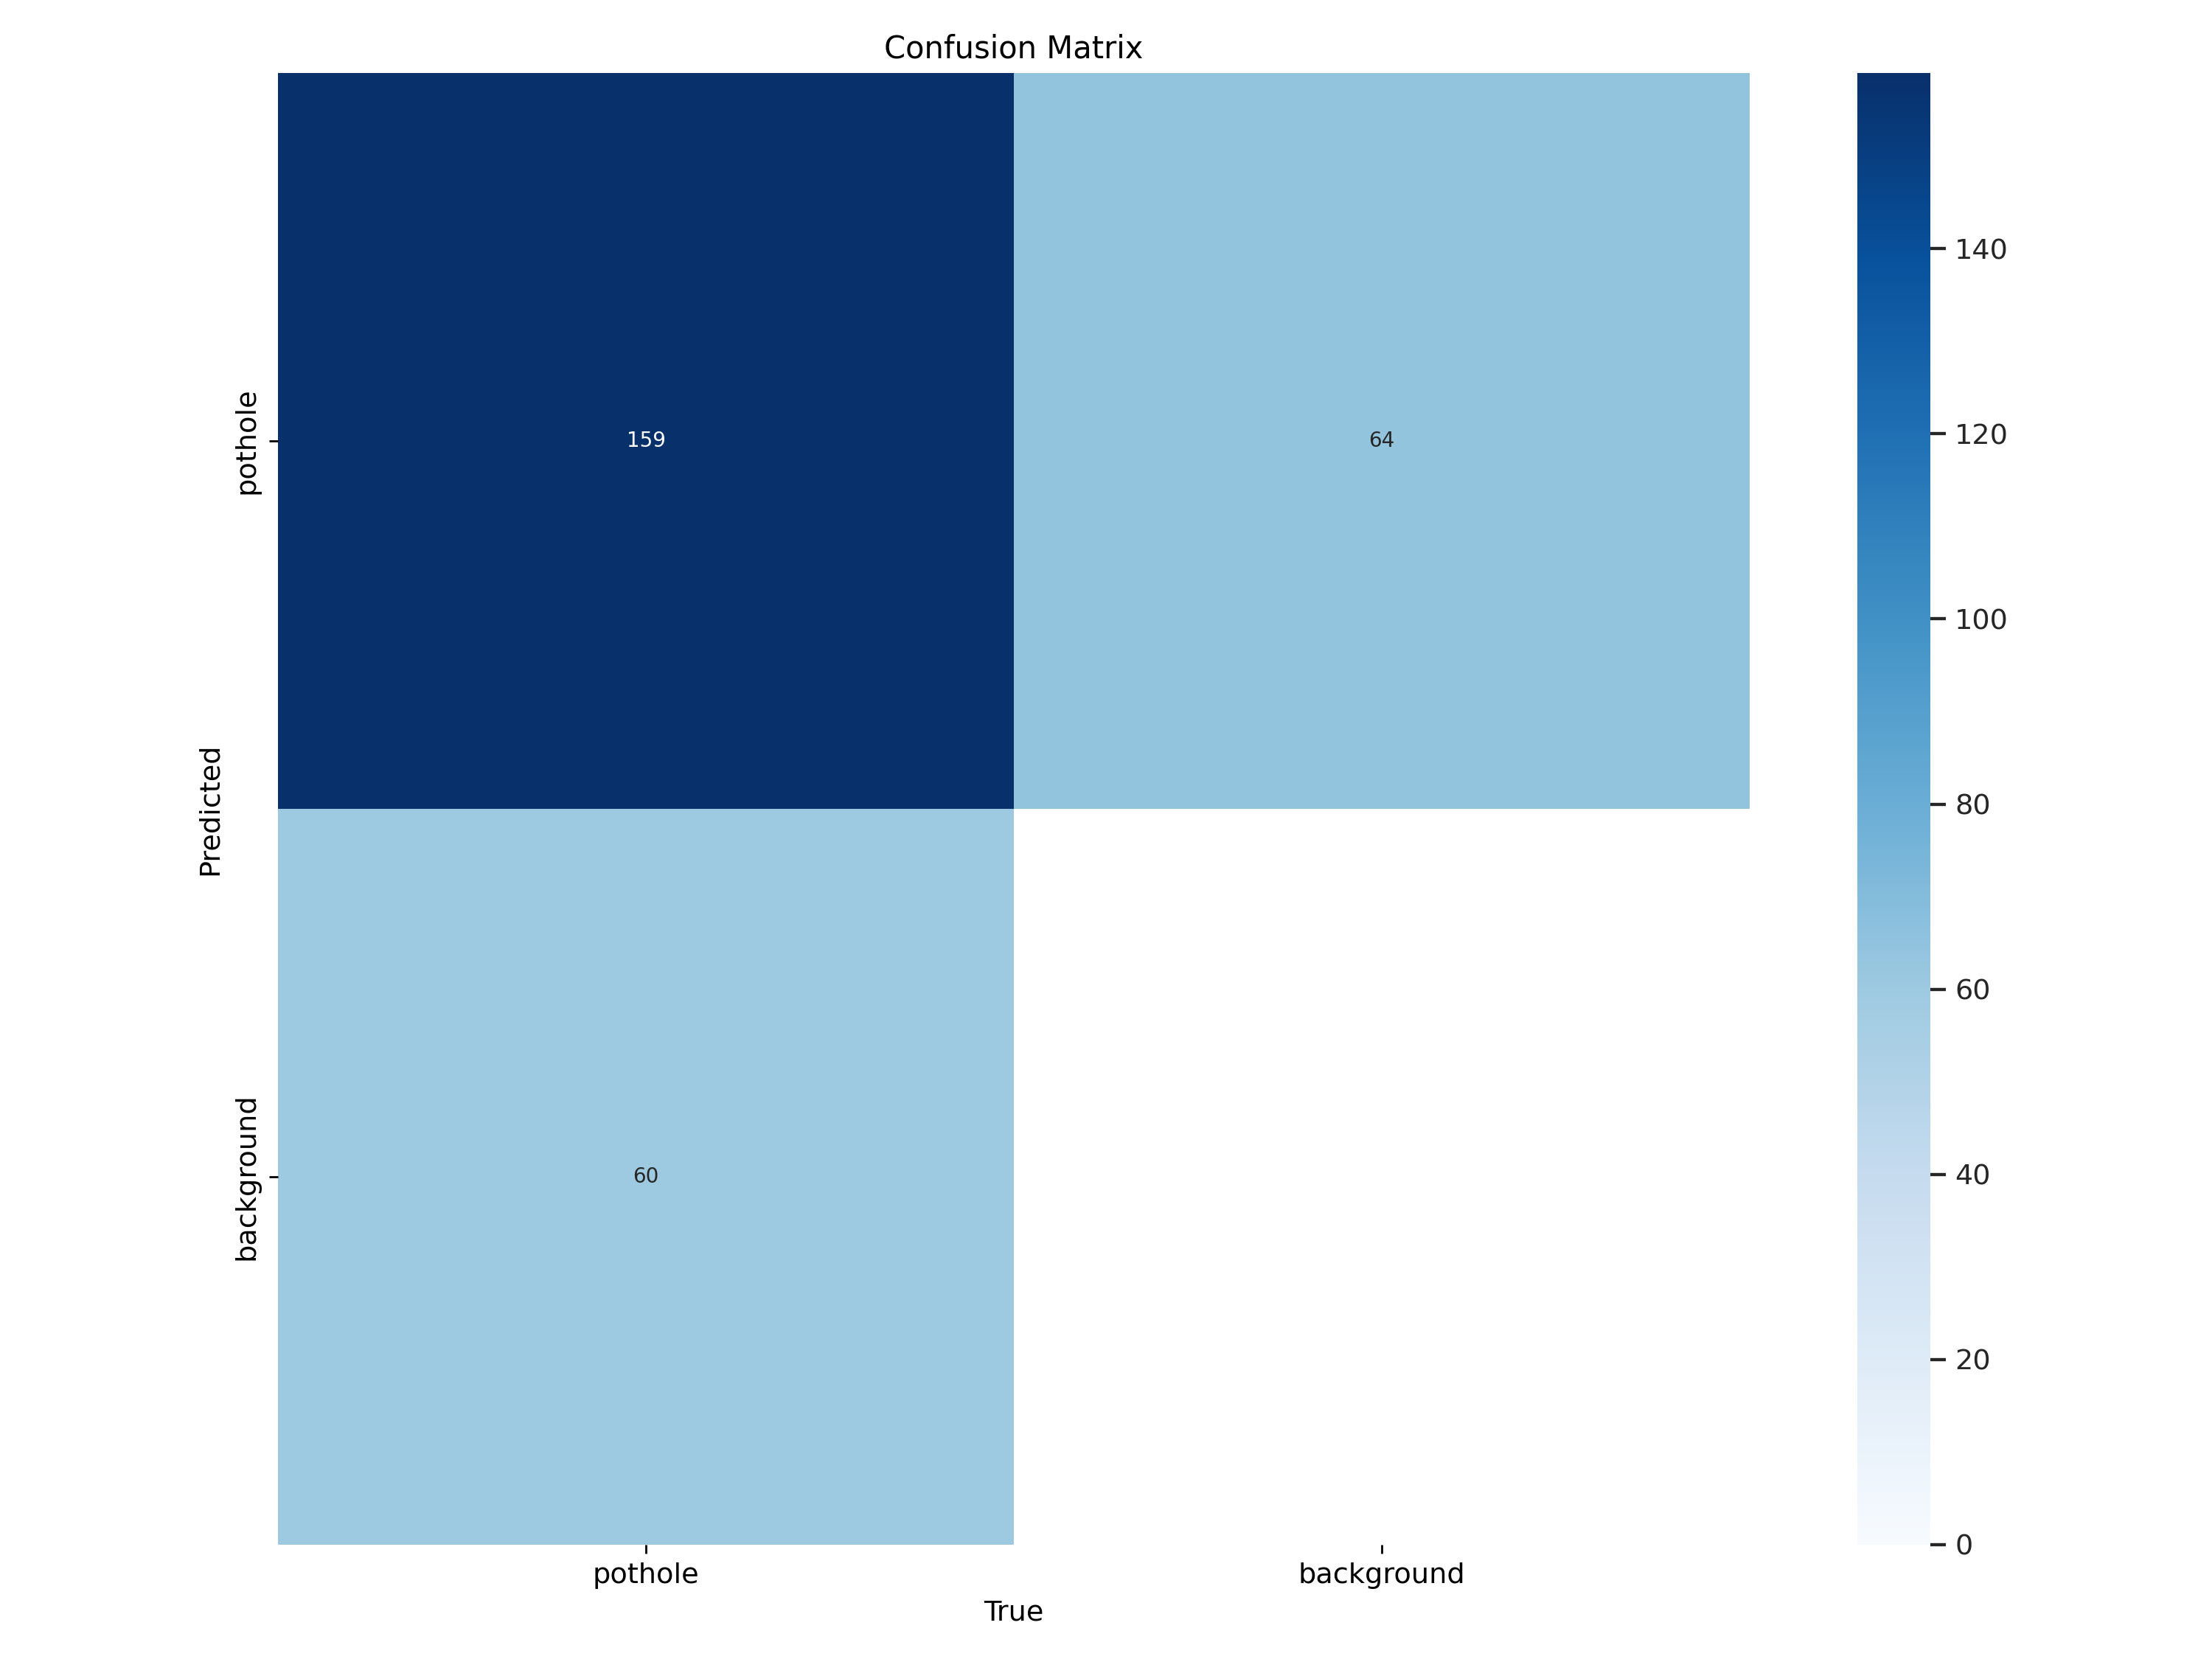

In [34]:
%cd {HOME}

Image(filename = f'{HOME}/runs/detect/train/confusion_matrix.png', width = 900)

/content


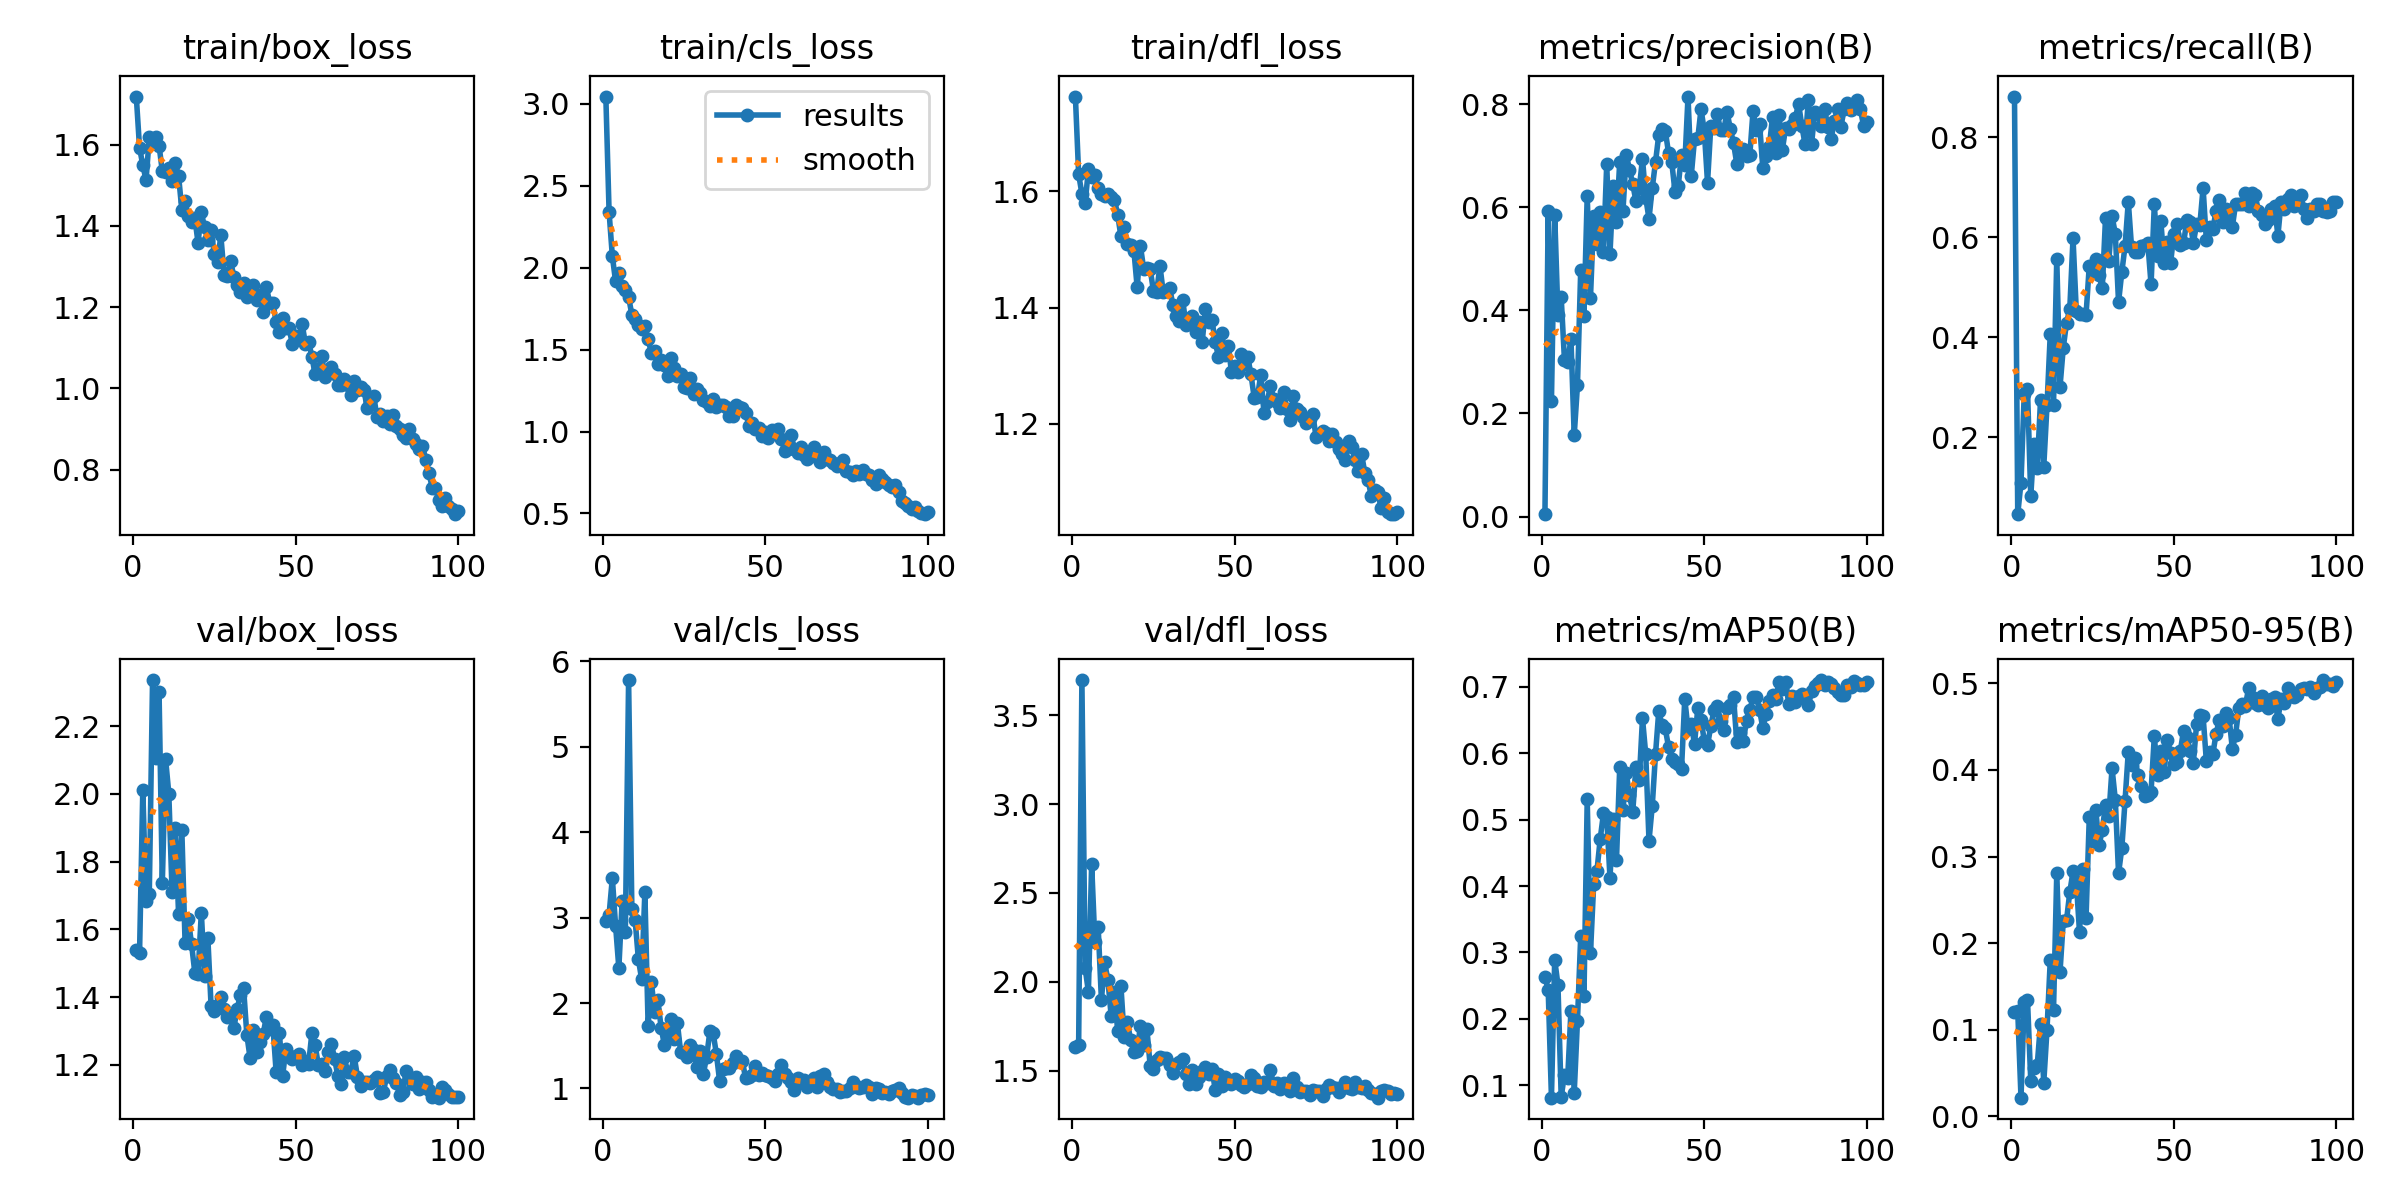

In [35]:
%cd {HOME}

Image(filename = f'{HOME}/runs/detect/train/results.png', width = 600)

/content


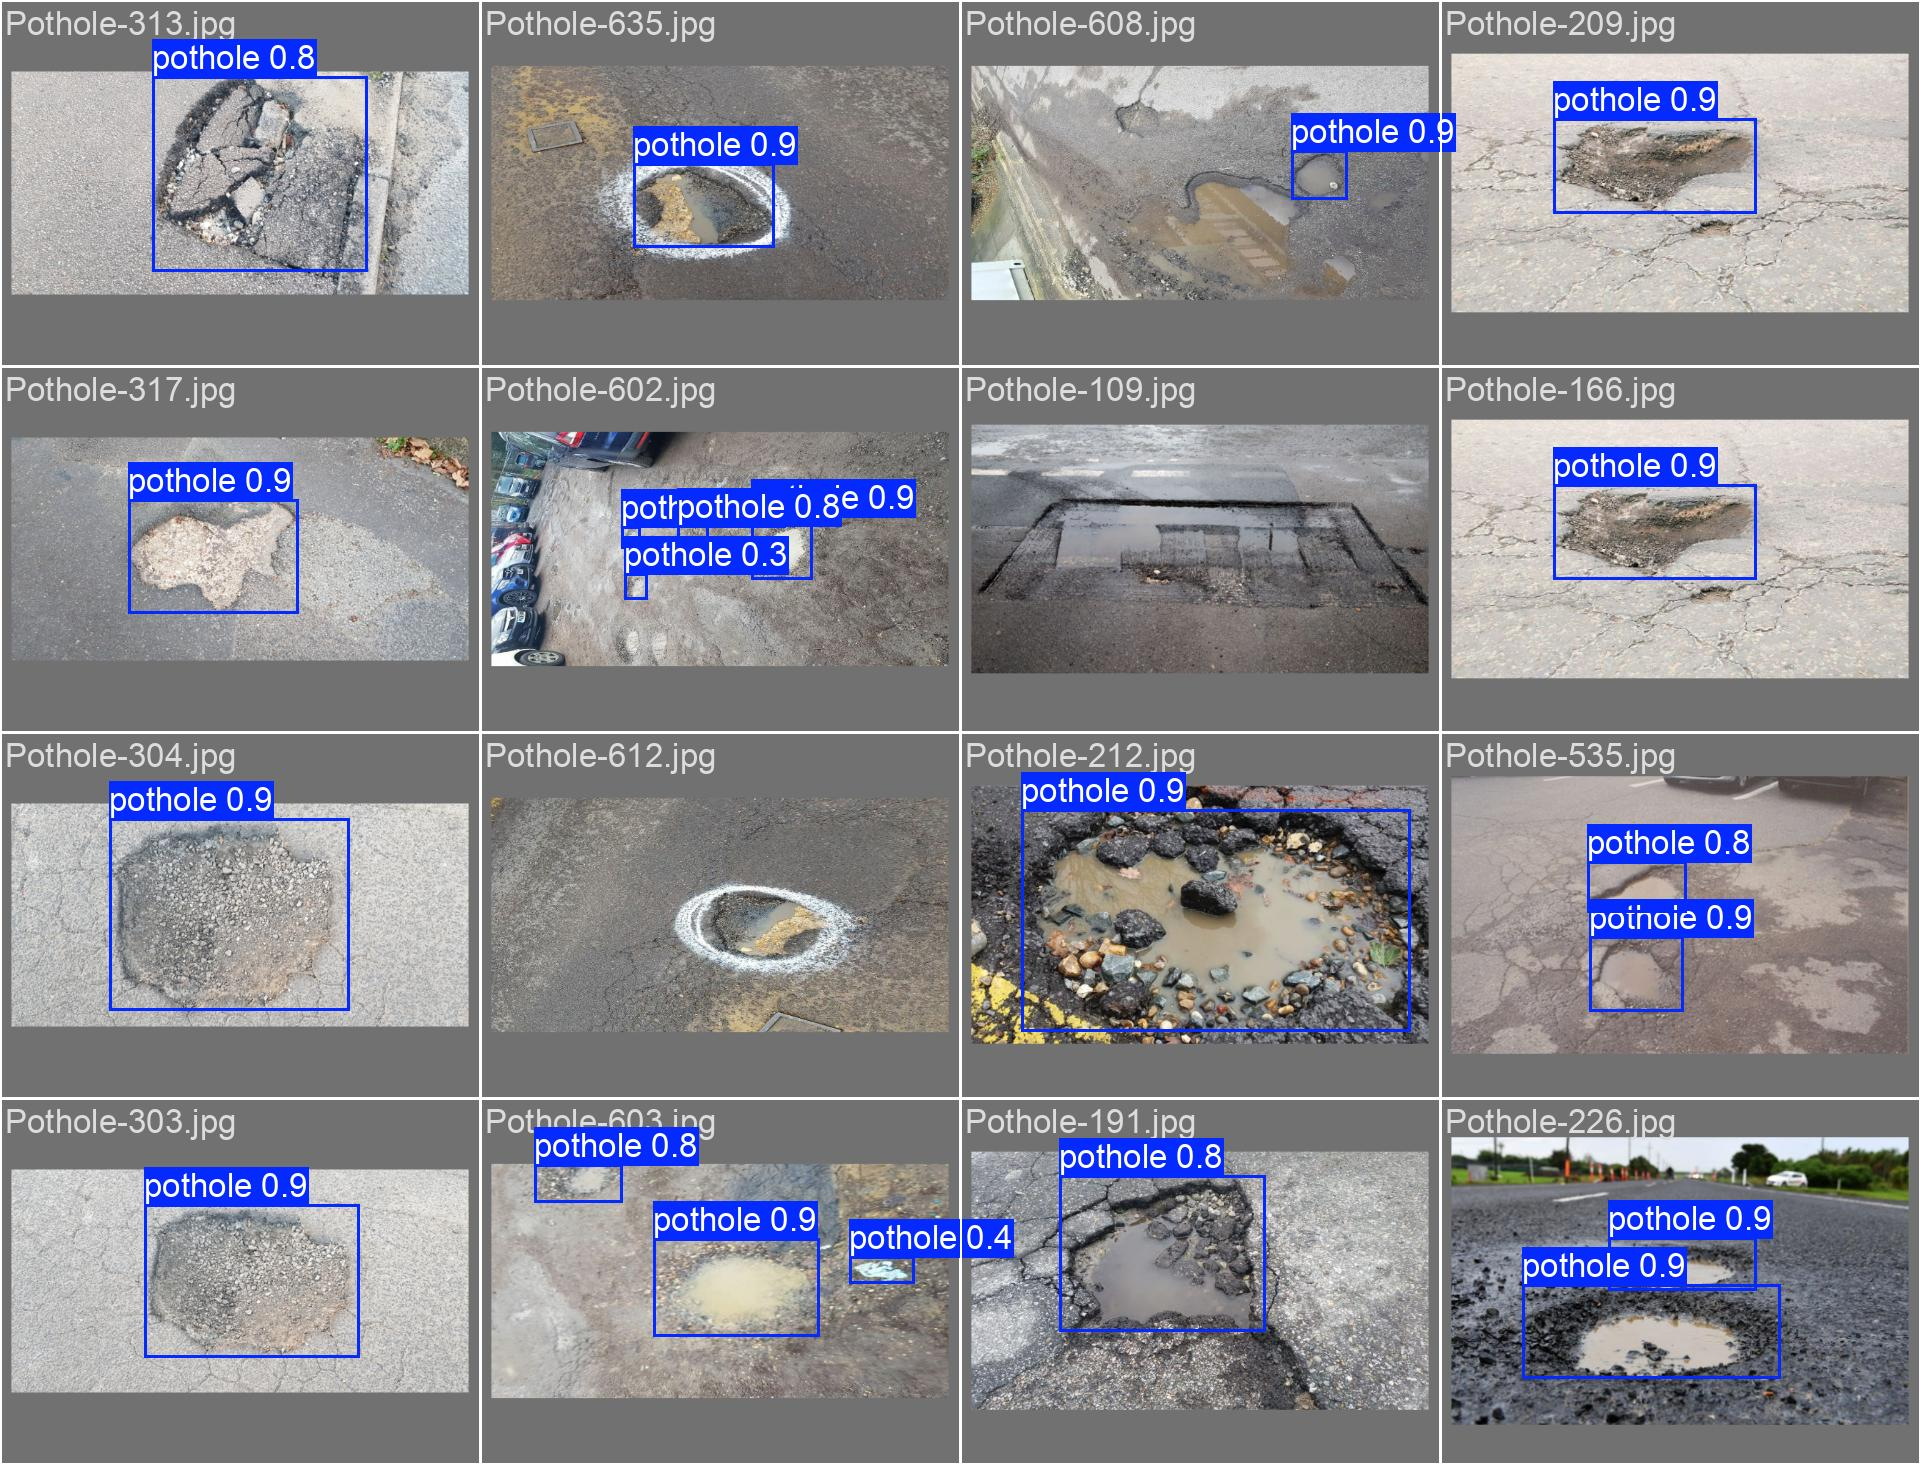

In [36]:
%cd {HOME}

Image(filename = f'{HOME}/runs/detect/train/val_batch0_pred.jpg', width = 600)

In [38]:
%cd {HOME}

!yolo task=detect mode=val model={HOME}/runs/detect/train/weights/best.pt data=/content/datasets/data.yaml

/content
Ultralytics 8.3.116 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1051.7±349.3 MB/s, size: 83.3 KB)
val: Scanning /content/datasets/val/labels.cache... 142 images, 0 backgrounds, 1 corrupt: 100% 142/142 [00:00<?, ?it/s]
val: /content/datasets/val/images/Pothole-261.jpg: ignoring corrupt image/label: non-normalized or out of bounds coordinates [     5.5255      1.4888      2.2653      1.1414]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% 9/9 [00:02<00:00,  3.71it/s]
                   all        141        219      0.803      0.658      0.712      0.503
Speed: 0.7ms preprocess, 6.3ms inference, 0.0ms loss, 2.7ms postprocess per image
Results saved to runs/detect/val2
💡 Learn more at https://docs.ultralytics.com/modes/val


In [39]:
%cd {HOME}
!yolo task=detect mode=predict model={HOME}/runs/detect/train/weights/best.pt conf=0.25 source=/content/datasets/test/images

/content
Ultralytics 8.3.116 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs

image 1/72 /content/datasets/test/images/Pothole-003.jpg: 640x320 2 potholes, 33.8ms
image 2/72 /content/datasets/test/images/Pothole-020.jpg: 640x320 2 potholes, 6.8ms
image 3/72 /content/datasets/test/images/Pothole-029.jpg: 640x320 3 potholes, 6.4ms
image 4/72 /content/datasets/test/images/Pothole-043.jpg: 480x640 1 pothole, 36.9ms
image 5/72 /content/datasets/test/images/Pothole-047.jpg: 448x640 4 potholes, 33.4ms
image 6/72 /content/datasets/test/images/Pothole-054.jpg: 448x640 1 pothole, 6.0ms
image 7/72 /content/datasets/test/images/Pothole-068.jpg: 640x480 1 pothole, 31.6ms
image 8/72 /content/datasets/test/images/Pothole-074.jpg: 480x640 1 pothole, 6.6ms
image 9/72 /content/datasets/test/images/Pothole-082.jpg: 448x640 1 pothole, 6.5ms
image 10/72 /content/datasets/test/images/Pothole-090.jpg: 448x640 2 pot

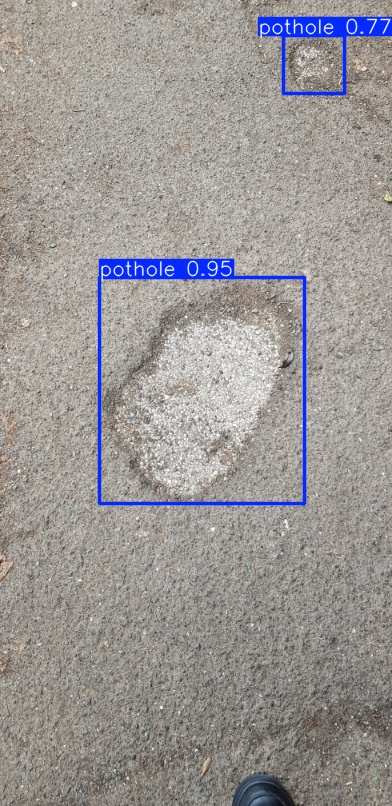

In [40]:
Image('/content/runs/detect/predict/Pothole-020.jpg')


In [43]:
import shutil

# Path to the directory you want to download
directory_path = '/content/runs'  # Example

# Zip the directory
shutil.make_archive('/content/datasets', 'zip', directory_path)


'/content/datasets.zip'

In [46]:
from ultralytics import YOLO

# Load a model
model = YOLO('/content/KaggleModel.pt')  # load a custom trained model

# Export the model
model.export(format='tflite')

Ultralytics 8.3.116 🚀 Python-3.11.12 torch-2.6.0+cu124 CPU (Intel Xeon 2.00GHz)
Model summary (fused): 72 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs

PyTorch: starting from '/content/KaggleModel.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 5, 8400) (5.9 MB)
requirements: Ultralytics requirement ['protobuf>=5'] not found, attempting AutoUpdate...
Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 316.2/316.2 kB 11.6 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 3.20.3
    Uninstalling protobuf-3.20.3:
      Successfully uninstalled protobuf-3.20.3

requirements: AutoUpdate success ✅ 5.1s, installed 1 package: ['protobuf>=5']
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


TensorFlow SavedModel: starting export with tensorflow 2.18.0...

ONNX: starting export with onnx 1.17.0 opset 19...
ONNX: slimming with

'/content/KaggleModel_saved_model/KaggleModel_float32.tflite'

Collecting workspace informationHere's a comprehensive explanation of the HoleYeahFinal.ipynb notebook that you can share with an LLM:

---

## **HoleYea Model Training Notebook - Complete Breakdown**

### **Overview**
This is a **YOLOv8 object detection model training pipeline** for pothole detection. The notebook trains a custom YOLOv8 nano model on a pothole dataset and exports it to multiple formats (TFLite, ONNX) for mobile/edge deployment.

### **Key Sections & Flow**

#### **1. Setup & Initialization**
- **Imports**: `os`, `glob`, `IPython.display`
- **GPU Check**: `!nvidia-smi` — verifies CUDA availability
- **Home Directory**: Sets `HOME` to current working directory
- **Dependencies**: Installs `ultralytics` (YOLOv8), `fastapi`, `kaleido`, `python_multipart`, `uvicorn`

#### **2. Model Training**
- **Framework**: YOLOv8 Nano (`yolov8n.pt`)
- **Training Command**:
  ```
  yolo task=detect mode=train model=yolov8n.pt data=/content/datasets/data.yaml epochs=100 batch=32 imgsz=640 device=0 amp=True
  ```
- **Parameters**:
  - `epochs=100`: 100 training iterations
  - `batch=32`: Batch size of 32
  - `imgsz=640`: Input image size 640×640
  - `device=0`: GPU device 0
  - `amp=True`: Automatic Mixed Precision (faster training)
- **Dataset**: Requires `data.yaml` at `/content/datasets/data.yaml` with train/val/test splits

#### **3. Model Evaluation & Visualization**
- **Validation**: Runs validation on the best trained model (`best.pt`)
- **Outputs Generated**:
  - `confusion_matrix.png` — Class-wise confusion matrix
  - `results.png` — Training metrics (precision, recall, mAP, loss)
  - `val_batch0_pred.jpg` — Sample validation batch with predictions
- **Predictions**: Inference on test set with confidence threshold `conf=0.25`

#### **4. Model Export**
- **Best Model Path**: `{HOME}/runs/detect/train/weights/best.pt`
- **Export to TFLite**:
  ```python
  model = YOLO('/content/KaggleModel.pt')
  model.export(format='tflite')
  ```
- **Purpose**: Convert trained `.pt` model → `.tflite` for mobile deployment

---

### **Dataset Structure**


In [ ]:
/content/datasets/
├── data.yaml          # Dataset config (class names, paths)
├── images/
│   ├── train/        # Training images
│   ├── val/          # Validation images
│   └── test/         # Test images
└── labels/
    ├── train/        # Training annotations (YOLO format)
    ├── val/          # Validation annotations
    └── test/         # Test annotations



---

### **Model Details**

| Aspect | Value |
|--------|-------|
| **Architecture** | YOLOv8 Nano (smallest variant) |
| **Task** | Object Detection (single class: pothole) |
| **Input Size** | 640×640 pixels |
| **Output Format** | Bounding boxes + confidence scores |
| **Export Formats** | `.pt` (PyTorch), `.tflite` (TensorFlow Lite) |
| **Thresholds** | Confidence: 0.25, NMS: 0.45 (inferred from codebase) |

---

### **Output Models in Project**

Located in Android Models:
- **colabmodel.tflite** — Trained from Colab (TFLite format)
- **ColabModel.onnx** — Colab model in ONNX format
- **KaggleModel.tflite** — Kaggle dataset variant
- **KaggleModel.onnx** — Kaggle ONNX variant
- **labels.txt** — Class mapping: `0 pothole`

---

### **Integration with Mobile App**

The exported `.tflite` model is used in:
- **TFLiteService** — Loads & runs inference
- **Preprocessing**: Image resized to 640×640, YUV420→RGB conversion
- **Postprocessing**: Non-Maximum Suppression (NMS) to filter overlapping detections
- **Output**: List of `Detection` objects (x, y, width, height, confidence)

---

### **Training Artifacts Generated**


In [ ]:
/runs/detect/train/
├── weights/
│   ├── best.pt          # Best model checkpoint
│   └── last.pt          # Last epoch checkpoint
├── confusion_matrix.png
├── results.png
├── val_batch0_pred.jpg
└── ...other metrics



---

This notebook is a **standard YOLOv8 training pipeline** optimized for pothole detection with multi-format export capabilities for deployment across mobile (Flutter) and edge devices.